In [1]:
!mkdir data

In [3]:
from google.colab import files
files.upload()

Saving data.zip to data.zip


{'data.zip': b'PK\x03\x04\n\x00\x00\x00\x00\x00\xa2t%\\\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x05\x00\x1c\x00data/UT\t\x00\x03\x8f\xcc[i\x07\xd8[iux\x0b\x00\x01\x04\x00\x00\x00\x00\x04\x00\x00\x00\x00PK\x03\x04\x14\x00\x00\x00\x08\x00\xa2t%\\\xa2\xa7\x1e+B\xad\x04\x00&?\x10\x00\x14\x00\x1c\x00data/dataset_raw.csvUT\t\x00\x03\x8f\xcc[i\x8a\xd6[iux\x0b\x00\x01\x04\x00\x00\x00\x00\x04\x00\x00\x00\x00\xec\\\xcb\xae\x1bGz\xde\xcfS\x14\xceb\x90\t\xba\xe8\xea\xee\xea\x1bWCK\xb2%\xcb\xd2(>2<\xb3qP\xd5UM\xf6i\xb2I\xf4\xc5\xc2\xd1.\x0f\x90Ev\xd9y\x95}\x90m\x16\x01\xf2B\xf1#\xe4\xfb\xab\x9bd\xf36\x03\x03\x1e\xc08\x96$\xf0\x90\x87u\xfdo\xdf\xf7\xffU\xad\xff\xfb\xef\xffQ\xbb\xdd?\x97\xc6k\xec\x0f\xa5\xfd\xf0\xcax}k\x9b\xb7jc\xbd6\xdf6\xd6S\x9d\x97o\xeb\xce\xd6\x9d\xd7\xad\xfa\x8dn\xbf\xdd=\xdb\xf6\xf8\xd4\xd8\xdd\xfa\xf1\xd9\xf8\x15}(\xadYt\xdeZi\xbb\xfe]\xbe\xdd\xcc\xda\xd5vg\xed\x0cc\xa7y\x96FZ\xc6\\H\x13q\xa9T\xc0S\xa35WA.\x13\x9b\xdb$K\n\xef\xad\xea\x1b\xc5\xdey\x91\x17\x88\x00M}\xb4f

In [4]:
!unzip -o data.zip

Archive:  data.zip
  inflating: data/dataset_raw.csv    


In [5]:
!ls data

dataset_raw.csv


In [6]:
!pip -q install tensorflow scikit-learn pandas

In [7]:
import os, random
import numpy as np
import tensorflow as tf

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Seed:", SEED)

Seed: 42


In [8]:
import pandas as pd
import re, string

df_raw = pd.read_csv("data/dataset_raw.csv")
df_raw = df_raw[["content", "label"]].copy()

print(df_raw.shape)
print(df_raw["label"].value_counts())
df_raw.head()

(3200, 2)
label
positif    1996
negatif    1033
netral      171
Name: count, dtype: int64


,content,label
0,selalu puas dengan pesanan . rata* sesuai dgn ...,positif
1,sangat membantu.. keren,positif
2,penjualnya ga niat jualan,negatif
3,sangat bagus,positif
4,pembelian bisa transfer langsung memudahkan tr...,positif


In [9]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)   # URL
    text = re.sub(r"\d+", "", text)              # angka
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_raw["clean_text"] = df_raw["content"].apply(clean_text)

In [10]:
label_map = {"negatif": 0, "netral": 1, "positif": 2}
df_raw["label_encoded"] = df_raw["label"].map(label_map)

print(df_raw["label_encoded"].value_counts())
print("NaN label:", df_raw["label_encoded"].isna().sum())

label_encoded
2    1996
0    1033
1     171
Name: count, dtype: int64
NaN label: 0


In [11]:
df_raw[["clean_text", "label_encoded"]].to_csv("data/dataset_clean.csv", index=False)
print("Saved: data/dataset_clean.csv")

Saved: data/dataset_clean.csv


In [12]:
df2 = pd.read_csv("data/dataset_clean.csv")
df2["clean_text"] = df2["clean_text"].fillna("").astype(str).str.strip()

df2["word_count"] = df2["clean_text"].apply(lambda x: len(x.split()))
df2 = df2[df2["word_count"] >= 2].drop(columns=["word_count"]).reset_index(drop=True)

print("Total setelah filter:", len(df2))
print(df2["label_encoded"].value_counts())
df2.head()


Total setelah filter: 2622
label_encoded
2    1454
0    1004
1     164
Name: count, dtype: int64


,clean_text,label_encoded
0,selalu puas dengan pesanan rata sesuai dgn yg ...,2
1,sangat membantu keren,2
2,penjualnya ga niat jualan,0
3,sangat bagus,2
4,pembelian bisa transfer langsung memudahkan tr...,2


In [13]:
from sklearn.utils import resample

df_neg = df2[df2.label_encoded == 0]
df_neu = df2[df2.label_encoded == 1]
df_pos = df2[df2.label_encoded == 2]

target_n = len(df_neg)
df_neu_up = resample(df_neu, replace=True, n_samples=target_n, random_state=42)

df_bal = (
    pd.concat([df_neg, df_neu_up, df_pos], axis=0)
      .sample(frac=1, random_state=42)
      .reset_index(drop=True)
)

print(df_bal["label_encoded"].value_counts())

label_encoded
2    1454
0    1004
1    1004
Name: count, dtype: int64


In [14]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

X = df_bal["clean_text"].astype(str).values
y = df_bal["label_encoded"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vocab_size = 20000
max_len = 70

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_len, padding="post", truncating="post")
X_test_pad  = pad_sequences(tokenizer.texts_to_sequences(X_test),  maxlen=max_len, padding="post", truncating="post")

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model_cnn = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    Conv1D(128, 3, activation="relu"),
    Conv1D(128, 5, activation="relu"),
    GlobalMaxPooling1D(),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dense(3, activation="softmax")
])

model_cnn.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
early = EarlyStopping(monitor="val_accuracy", patience=2, restore_best_weights=True)

model_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = model_cnn.fit(
    X_train_pad, y_train,
    epochs=12,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early],
    verbose=1
)

Epoch 1/12
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.4864 - loss: 1.0154 - val_accuracy: 0.6354 - val_loss: 0.8230
Epoch 2/12
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.7434 - loss: 0.6327 - val_accuracy: 0.8051 - val_loss: 0.5633
Epoch 3/12
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.9151 - loss: 0.2495 - val_accuracy: 0.8321 - val_loss: 0.5284
Epoch 4/12
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.9678 - loss: 0.1033 - val_accuracy: 0.8339 - val_loss: 0.6642
Epoch 5/12
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.9775 - loss: 0.0612 - val_accuracy: 0.8466 - val_loss: 0.7106
Epoch 6/12
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.9890 - loss: 0.0382 - val_accuracy: 0.8412 - val_loss: 0.7039
Epoch 7/12
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - accuracy: 0.9941 - loss: 0.0219 - val_accuracy: 0.8375 - val_loss: 0.9159


In [17]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = np.argmax(model_cnn.predict(X_test_pad), axis=1)

acc1 = accuracy_score(y_test, y_pred)
print("Accuracy SKEMA 1:", acc1)
print(classification_report(y_test, y_pred, target_names=["negatif","netral","positif"]))
print(confusion_matrix(y_test, y_pred))

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
Accuracy SKEMA 1: 0.8787878787878788
              precision    recall  f1-score   support

     negatif       0.83      0.80      0.81       201
      netral       0.94      0.99      0.96       201
     positif       0.87      0.86      0.86       291

    accuracy                           0.88       693
   macro avg       0.88      0.88      0.88       693
weighted avg       0.88      0.88      0.88       693

[[160   4  37]
 [  1 198   2]
 [ 31   9 251]]


Skema 2 (CNN baseline)

CNN tanpa oversampling + split 80/20

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense

X2 = df2["clean_text"].astype(str).values
y2 = df2["label_encoded"].values

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

tokenizer2 = Tokenizer(num_words=20000, oov_token="<OOV>")
tokenizer2.fit_on_texts(X2_train)

X2_train_pad = pad_sequences(tokenizer2.texts_to_sequences(X2_train), maxlen=70, padding="post", truncating="post")
X2_test_pad  = pad_sequences(tokenizer2.texts_to_sequences(X2_test),  maxlen=70, padding="post", truncating="post")

model_cnn2 = Sequential([
    Embedding(20000, 128, input_length=70),
    Conv1D(128, 3, activation="relu"),
    GlobalMaxPooling1D(),
    Dense(3, activation="softmax")
])

model_cnn2.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history2 = model_cnn2.fit(
    X2_train_pad, y2_train,
    epochs=6,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

y2_pred = np.argmax(model_cnn2.predict(X2_test_pad), axis=1)
acc2 = accuracy_score(y2_test, y2_pred)
print("Accuracy SKEMA 2:", acc2)


Epoch 1/6


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.5982 - loss: 0.9015 - val_accuracy: 0.7262 - val_loss: 0.7179
Epoch 2/6
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.8239 - loss: 0.5692 - val_accuracy: 0.7810 - val_loss: 0.5757
Epoch 3/6
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.8861 - loss: 0.3671 - val_accuracy: 0.7905 - val_loss: 0.5600
Epoch 4/6
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9144 - loss: 0.2446 - val_accuracy: 0.7857 - val_loss: 0.5845
Epoch 5/6
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.9429 - loss: 0.1582 - val_accuracy: 0.8000 - val_loss: 0.6285
Epoch 6/6
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9850 - loss: 0.0952 - val_accuracy: 0.7929 - val_loss: 0.7034
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Accuracy SKEMA 2: 0.7942857142857143


Skema 3

BiLSTM + oversampling + split 70/30

In [19]:
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X3 = df_bal["clean_text"].astype(str).values
y3 = df_bal["label_encoded"].values

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.3, random_state=42, stratify=y3
)

tokenizer3 = Tokenizer(num_words=20000, oov_token="<OOV>")
tokenizer3.fit_on_texts(X3_train)

X3_train_pad = pad_sequences(tokenizer3.texts_to_sequences(X3_train), maxlen=70, padding="post", truncating="post")
X3_test_pad  = pad_sequences(tokenizer3.texts_to_sequences(X3_test),  maxlen=70, padding="post", truncating="post")

model_bilstm3 = Sequential([
    Embedding(20000, 128, input_length=70),
    Bidirectional(LSTM(64)),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dense(3, activation="softmax")
])

model_bilstm3.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history3 = model_bilstm3.fit(
    X3_train_pad, y3_train,
    epochs=6,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

y3_pred = np.argmax(model_bilstm3.predict(X3_test_pad), axis=1)
acc3 = accuracy_score(y3_test, y3_pred)
print("Accuracy SKEMA 3:", acc3)


Epoch 1/6


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


61/61 ━━━━━━━━━━━━━━━━━━━━ 12s 121ms/step - accuracy: 0.4623 - loss: 1.0263 - val_accuracy: 0.6000 - val_loss: 0.7899
Epoch 2/6
61/61 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - accuracy: 0.6904 - loss: 0.7142 - val_accuracy: 0.8124 - val_loss: 0.5087
Epoch 3/6
61/61 ━━━━━━━━━━━━━━━━━━━━ 13s 143ms/step - accuracy: 0.9006 - loss: 0.2914 - val_accuracy: 0.8495 - val_loss: 0.4736
Epoch 4/6
61/61 ━━━━━━━━━━━━━━━━━━━━ 8s 134ms/step - accuracy: 0.9586 - loss: 0.1315 - val_accuracy: 0.8557 - val_loss: 0.5443
Epoch 5/6
61/61 ━━━━━━━━━━━━━━━━━━━━ 10s 168ms/step - accuracy: 0.9769 - loss: 0.0778 - val_accuracy: 0.8495 - val_loss: 0.5520
Epoch 6/6
61/61 ━━━━━━━━━━━━━━━━━━━━ 18s 117ms/step - accuracy: 0.9912 - loss: 0.0403 - val_accuracy: 0.8495 - val_loss: 0.6427
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
Accuracy SKEMA 3: 0.861405197305101


GRAFIK AKURASI (SKEMA 1, 2 DAN 3)

In [20]:
import matplotlib.pyplot as plt

def plot_history(history, title_prefix="Model"):
    acc = history.history.get("accuracy", [])
    val_acc = history.history.get("val_accuracy", [])
    loss = history.history.get("loss", [])
    val_loss = history.history.get("val_loss", [])

    epochs = range(1, len(acc) + 1)

    # Accuracy
    plt.figure()
    plt.plot(epochs, acc)
    plt.plot(epochs, val_acc)
    plt.title(f"{title_prefix} - Akurasi")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend(["Training", "Validation"])
    plt.show()

    # Loss
    plt.figure()
    plt.plot(epochs, loss)
    plt.plot(epochs, val_loss)
    plt.title(f"{title_prefix} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(["Training", "Validation"])
    plt.show()


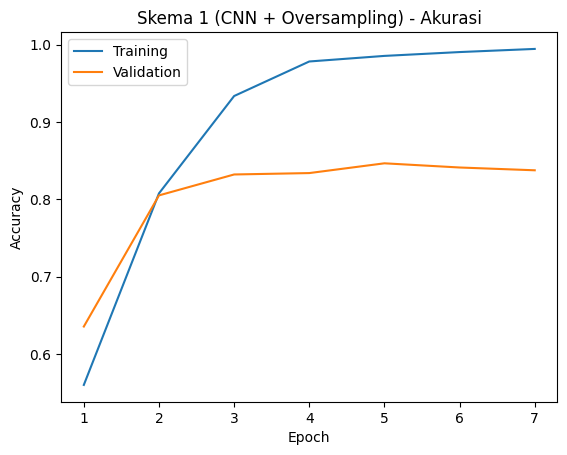

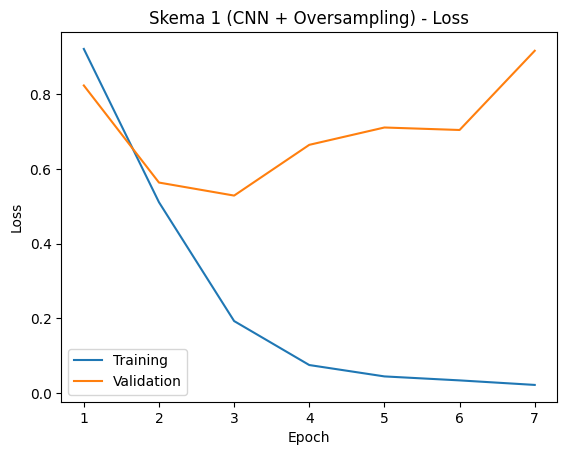

In [23]:
plot_history(history, "Skema 1 (CNN + Oversampling)")

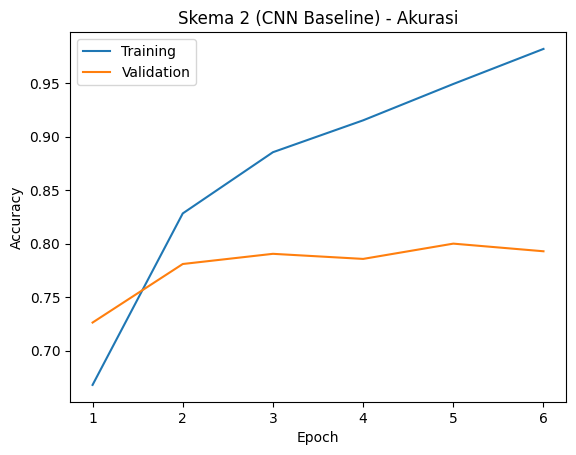

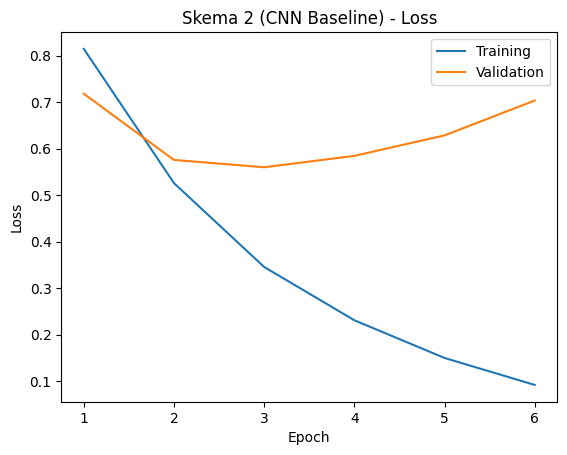

In [24]:
plot_history(history2, "Skema 2 (CNN Baseline)")

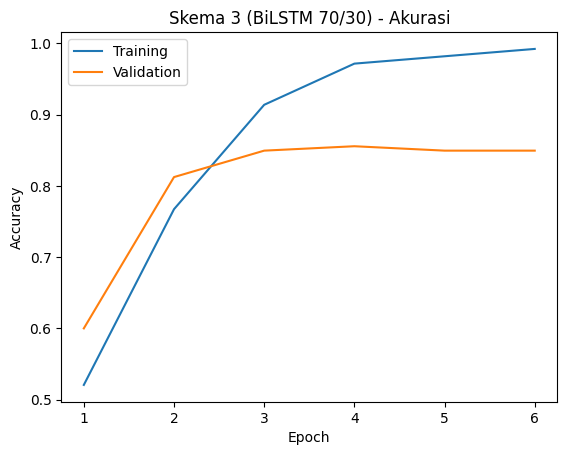

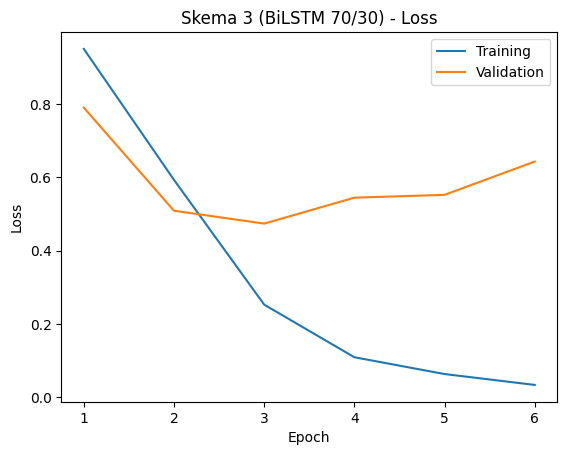

In [25]:
plot_history(history3, "Skema 3 (BiLSTM 70/30)")

Inference Model terbaik (Skema 1)

In [26]:
label_inv = {0:"negatif", 1:"netral", 2:"positif"}

def predict_sentiment(text: str):
    text = str(text).strip().lower()
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=max_len, padding="post", truncating="post")
    prob = model_cnn.predict(pad, verbose=0)[0]
    pred_id = int(np.argmax(prob))
    return label_inv[pred_id], float(np.max(prob)), prob

examples = [
    "Aplikasinya bagus banget, fiturnya lengkap dan cepat",
    "Error terus, tidak bisa login, parah",
    "Lumayan sih, tapi masih sering lemot"
]

for t in examples:
    label, conf, prob = predict_sentiment(t)
    print("Teks:", t)
    print("Prediksi:", label, "| Confidence:", round(conf, 4))
    print("Prob:", prob)
    print("-"*50)


Teks: Aplikasinya bagus banget, fiturnya lengkap dan cepat
Prediksi: positif | Confidence: 0.9997
Prob: [1.8104704e-04 8.6936598e-05 9.9973196e-01]
--------------------------------------------------
Teks: Error terus, tidak bisa login, parah
Prediksi: negatif | Confidence: 0.9807
Prob: [9.8070621e-01 1.9284472e-02 9.3391291e-06]
--------------------------------------------------
Teks: Lumayan sih, tapi masih sering lemot
Prediksi: negatif | Confidence: 0.6354
Prob: [0.6354254  0.34772095 0.01685371]
--------------------------------------------------


In [27]:
!pip freeze > requirements.txt

In [ ]:
from google.colab import files
files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!zip -r data.zip data

updating: data/ (stored 0%)
updating: data/dataset_raw.csv (deflated 71%)
updating: data/dataset_clean.csv (deflated 66%)


In [ ]:
from google.colab import files
files.download("data.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>